# MonteCore Finance — Transaction Anomaly Detection

## Phase 4: Unsupervised Transaction Anomaly Detection

This notebook develops the transaction anomaly detection component of MonteCore Finance.

Unlike the supervised AML classifier developed in Phase 3, this component uses unsupervised machine learning to identify transactions that exhibit unusual behavioural patterns without requiring known fraud or laundering labels.

Planned approaches include:

- Isolation Forest
- DBSCAN
- Behavioural anomaly scoring
- Explainable anomaly indicators

> An anomalous transaction is not necessarily fraudulent. Anomaly scores are intended to support investigation and prioritization rather than autonomous financial decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
anomaly_path = "../data/raw/transaction_anomaly/bank_transactions_data_2.csv"

anomaly_df = pd.read_csv(anomaly_path)

print("Dataset shape:", anomaly_df.shape)
print()
print("Columns:")
print(anomaly_df.columns.tolist())

Dataset shape: (2512, 16)

Columns:
['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate']


In [3]:
anomaly_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [4]:
anomaly_df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [5]:
for column in anomaly_df.columns:
    print(f"{column}: {anomaly_df[column].nunique()} unique values")

TransactionID: 2512 unique values
AccountID: 495 unique values
TransactionAmount: 2455 unique values
TransactionDate: 2512 unique values
TransactionType: 2 unique values
Location: 43 unique values
DeviceID: 681 unique values
IP Address: 592 unique values
MerchantID: 100 unique values
Channel: 3 unique values
CustomerAge: 63 unique values
CustomerOccupation: 4 unique values
TransactionDuration: 288 unique values
LoginAttempts: 5 unique values
AccountBalance: 2510 unique values
PreviousTransactionDate: 360 unique values


In [6]:
print("Total missing values:", anomaly_df.isnull().sum().sum())
print("Duplicate rows:", anomaly_df.duplicated().sum())
print("Duplicate TransactionIDs:", anomaly_df["TransactionID"].duplicated().sum())

Total missing values: 0
Duplicate rows: 0
Duplicate TransactionIDs: 0


In [7]:
numerical_columns = [
    "TransactionAmount",
    "CustomerAge",
    "TransactionDuration",
    "LoginAttempts",
    "AccountBalance"
]

anomaly_df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionAmount,2512.0,297.593778,291.946243,0.26,81.885,211.14,414.5275,1919.11
CustomerAge,2512.0,44.673965,17.792198,18.00,27.000,45.00,59.0000,80.00
TransactionDuration,2512.0,119.643312,69.963757,10.00,63.000,112.50,161.0000,300.00
LoginAttempts,2512.0,1.124602,0.602662,1.00,1.000,1.00,1.0000,5.00
AccountBalance,2512.0,5114.302966,3900.942499,101.25,1504.370,4735.51,7678.8200,14977.99


In [8]:
categorical_columns = [
    "TransactionType",
    "Channel",
    "CustomerOccupation"
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(anomaly_df[column].value_counts())


--- TransactionType ---
TransactionType
Debit     1944
Credit     568
Name: count, dtype: int64

--- Channel ---
Channel
Branch    868
ATM       833
Online    811
Name: count, dtype: int64

--- CustomerOccupation ---
CustomerOccupation
Student     657
Doctor      631
Engineer    625
Retired     599
Name: count, dtype: int64


In [9]:
df = anomaly_df.copy()

df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])
df["PreviousTransactionDate"] = pd.to_datetime(df["PreviousTransactionDate"])

print("TransactionDate type:", df["TransactionDate"].dtype)
print("PreviousTransactionDate type:", df["PreviousTransactionDate"].dtype)

print("\nTransaction date range:")
print(df["TransactionDate"].min(), "to", df["TransactionDate"].max())

print("\nPrevious transaction date range:")
print(df["PreviousTransactionDate"].min(), "to", df["PreviousTransactionDate"].max())

TransactionDate type: datetime64[ns]
PreviousTransactionDate type: datetime64[ns]

Transaction date range:
2023-01-02 16:00:06 to 2024-01-01 18:21:50

Previous transaction date range:
2024-11-04 08:06:23 to 2024-11-04 08:12:23


In [10]:
print("Unique previous transaction dates:",
      df["PreviousTransactionDate"].nunique())

print("\nFirst 10 previous transaction dates:")
print(df["PreviousTransactionDate"].head(10))

invalid_previous_dates = (
    df["PreviousTransactionDate"] > df["TransactionDate"]
).sum()

print("\nPrevious date occurs AFTER transaction date:",
      invalid_previous_dates)

print("Total transactions:", len(df))

print(
    "Percentage invalid:",
    round(invalid_previous_dates / len(df) * 100, 2),
    "%"
)

Unique previous transaction dates: 360

First 10 previous transaction dates:
0   2024-11-04 08:08:08
1   2024-11-04 08:09:35
2   2024-11-04 08:07:04
3   2024-11-04 08:09:06
4   2024-11-04 08:06:39
5   2024-11-04 08:06:36
6   2024-11-04 08:10:09
7   2024-11-04 08:10:55
8   2024-11-04 08:11:14
9   2024-11-04 08:06:32
Name: PreviousTransactionDate, dtype: datetime64[ns]

Previous date occurs AFTER transaction date: 2512
Total transactions: 2512
Percentage invalid: 100.0 %


In [11]:
df = df.drop(columns=["PreviousTransactionDate"])

print("Working dataset shape:", df.shape)
print("PreviousTransactionDate present:",
      "PreviousTransactionDate" in df.columns)

Working dataset shape: (2512, 15)
PreviousTransactionDate present: False


In [12]:
df["TransactionHour"] = df["TransactionDate"].dt.hour
df["DayOfWeek"] = df["TransactionDate"].dt.dayofweek
df["IsWeekend"] = (
    df["DayOfWeek"] >= 5
).astype(int)

df[
    [
        "TransactionDate",
        "TransactionHour",
        "DayOfWeek",
        "IsWeekend"
    ]
].head(10)

,TransactionDate,TransactionHour,DayOfWeek,IsWeekend
0,2023-04-11 16:29:14,16,1,0
1,2023-06-27 16:44:19,16,1,0
2,2023-07-10 18:16:08,18,0,0
3,2023-05-05 16:32:11,16,4,0
4,2023-10-16 17:51:24,17,0,0
5,2023-04-03 17:15:01,17,0,0
6,2023-02-15 16:36:48,16,2,0
7,2023-05-08 17:47:59,17,0,0
8,2023-03-21 16:59:46,16,1,0
9,2023-03-31 16:06:57,16,4,0


In [13]:
print("Transaction Hour Distribution:")
print(df["TransactionHour"].value_counts().sort_index())

print("\nDay of Week Distribution:")
print(df["DayOfWeek"].value_counts().sort_index())

print("\nWeekend Distribution:")
print(df["IsWeekend"].value_counts())

Transaction Hour Distribution:
TransactionHour
16    1316
17     819
18     377
Name: count, dtype: int64

Day of Week Distribution:
DayOfWeek
0    1070
1     360
2     341
3     368
4     373
Name: count, dtype: int64

Weekend Distribution:
IsWeekend
0    2512
Name: count, dtype: int64


In [14]:
candidate_numeric_features = [
    "TransactionAmount",
    "CustomerAge",
    "TransactionDuration",
    "LoginAttempts",
    "AccountBalance",
    "TransactionHour",
    "DayOfWeek",
    "IsWeekend"
]

for feature in candidate_numeric_features:
    print(
        f"{feature}: "
        f"{df[feature].nunique()} unique values"
    )

TransactionAmount: 2455 unique values
CustomerAge: 63 unique values
TransactionDuration: 288 unique values
LoginAttempts: 5 unique values
AccountBalance: 2510 unique values
TransactionHour: 3 unique values
DayOfWeek: 5 unique values
IsWeekend: 1 unique values


In [15]:
account_stats = (
    df.groupby("AccountID")["TransactionAmount"]
    .agg(
        AccountAvgTransactionAmount="mean",
        AccountStdTransactionAmount="std",
        AccountTransactionCount="count"
    )
    .reset_index()
)

df = df.merge(
    account_stats,
    on="AccountID",
    how="left"
)

df[
    [
        "AccountID",
        "TransactionAmount",
        "AccountAvgTransactionAmount",
        "AccountStdTransactionAmount",
        "AccountTransactionCount"
    ]
].head(10)

,AccountID,TransactionAmount,AccountAvgTransactionAmount,AccountStdTransactionAmount,AccountTransactionCount
0,AC00128,14.09,460.698571,487.969555,7
1,AC00455,376.24,304.622857,240.297881,7
2,AC00019,126.29,237.047500,197.693348,4
3,AC00070,184.50,236.483750,275.157989,8
4,AC00411,13.45,280.796667,310.729033,6
5,AC00393,92.15,209.206250,138.797484,8
6,AC00199,7.08,7.080000,NaN,1
7,AC00069,171.42,231.082857,195.249550,7
8,AC00135,106.23,72.945000,47.072098,2
9,AC00385,815.96,591.600000,490.382013,7


In [16]:
account_count_summary = (
    df.groupby("AccountID")
    .size()
    .value_counts()
    .sort_index()
)

print("Transactions per account distribution:")
print(account_count_summary)

print("\nAccounts with only 1 transaction:",
      (df.groupby("AccountID").size() == 1).sum())

print("Total unique accounts:",
      df["AccountID"].nunique())

print("\nMissing AccountStdTransactionAmount values:",
      df["AccountStdTransactionAmount"].isna().sum())

Transactions per account distribution:
1     24
2     43
3     62
4     81
5     87
6     68
7     58
8     31
9     28
10     4
11     5
12     4
Name: count, dtype: int64

Accounts with only 1 transaction: 24
Total unique accounts: 495

Missing AccountStdTransactionAmount values: 24


In [17]:
df["AccountStdTransactionAmount"] = (
    df["AccountStdTransactionAmount"].fillna(0)
)

print(
    "Missing AccountStdTransactionAmount:",
    df["AccountStdTransactionAmount"].isna().sum()
)

print(
    "Minimum account transaction count:",
    df["AccountTransactionCount"].min()
)

Missing AccountStdTransactionAmount: 0
Minimum account transaction count: 1


In [18]:
df["AmountDeviationFromAccountAvg"] = (
    df["TransactionAmount"]
    - df["AccountAvgTransactionAmount"]
).abs()

df[
    [
        "AccountID",
        "TransactionAmount",
        "AccountAvgTransactionAmount",
        "AmountDeviationFromAccountAvg"
    ]
].head(10)

,AccountID,TransactionAmount,AccountAvgTransactionAmount,AmountDeviationFromAccountAvg
0,AC00128,14.09,460.698571,446.608571
1,AC00455,376.24,304.622857,71.617143
2,AC00019,126.29,237.047500,110.757500
3,AC00070,184.50,236.483750,51.983750
4,AC00411,13.45,280.796667,267.346667
5,AC00393,92.15,209.206250,117.056250
6,AC00199,7.08,7.080000,0.000000
7,AC00069,171.42,231.082857,59.662857
8,AC00135,106.23,72.945000,33.285000
9,AC00385,815.96,591.600000,224.360000


In [19]:
df["AmountDeviationZScore"] = np.where(
    df["AccountStdTransactionAmount"] > 0,
    df["AmountDeviationFromAccountAvg"]
    / df["AccountStdTransactionAmount"],
    0
)

df[
    [
        "AccountID",
        "TransactionAmount",
        "AccountAvgTransactionAmount",
        "AccountStdTransactionAmount",
        "AmountDeviationFromAccountAvg",
        "AmountDeviationZScore"
    ]
].head(10)

,AccountID,TransactionAmount,AccountAvgTransactionAmount,AccountStdTransactionAmount,AmountDeviationFromAccountAvg,AmountDeviationZScore
0,AC00128,14.09,460.698571,487.969555,446.608571,0.915239
1,AC00455,376.24,304.622857,240.297881,71.617143,0.298035
2,AC00019,126.29,237.047500,197.693348,110.757500,0.560249
3,AC00070,184.50,236.483750,275.157989,51.983750,0.188923
4,AC00411,13.45,280.796667,310.729033,267.346667,0.860385
5,AC00393,92.15,209.206250,138.797484,117.056250,0.843360
6,AC00199,7.08,7.080000,0.000000,0.000000,0.000000
7,AC00069,171.42,231.082857,195.249550,59.662857,0.305572
8,AC00135,106.23,72.945000,47.072098,33.285000,0.707107
9,AC00385,815.96,591.600000,490.382013,224.360000,0.457521


In [20]:
df["LogTransactionAmount"] = np.log1p(
    df["TransactionAmount"]
)

df[
    [
        "TransactionAmount",
        "LogTransactionAmount"
    ]
].head(10)

,TransactionAmount,LogTransactionAmount
0,14.09,2.714032
1,376.24,5.932882
2,126.29,4.846468
3,184.50,5.223055
4,13.45,2.670694
5,92.15,4.534211
6,7.08,2.089392
7,171.42,5.149933
8,106.23,4.674976
9,815.96,6.705590


In [21]:
df["TransactionToBalanceRatio"] = (
    df["TransactionAmount"]
    / (df["AccountBalance"] + 1)
)

df[
    [
        "TransactionAmount",
        "AccountBalance",
        "TransactionToBalanceRatio"
    ]
].head(10)

,TransactionAmount,AccountBalance,TransactionToBalanceRatio
0,14.09,5112.21,0.002756
1,376.24,13758.91,0.027343
2,126.29,1122.35,0.112423
3,184.50,8569.06,0.021528
4,13.45,7429.40,0.001810
5,92.15,781.68,0.117736
6,7.08,13316.71,0.000532
7,171.42,2796.24,0.061282
8,106.23,9095.14,0.011679
9,815.96,1021.88,0.797708


In [22]:
df["TransactionToAccountAvgRatio"] = (
    df["TransactionAmount"]
    / (df["AccountAvgTransactionAmount"] + 1)
)

df[
    [
        "TransactionAmount",
        "AccountAvgTransactionAmount",
        "TransactionToAccountAvgRatio"
    ]
].head(10)

,TransactionAmount,AccountAvgTransactionAmount,TransactionToAccountAvgRatio
0,14.09,460.698571,0.030518
1,376.24,304.622857,1.231060
2,126.29,237.047500,0.530524
3,184.50,236.483750,0.776895
4,13.45,280.796667,0.047729
5,92.15,209.206250,0.438379
6,7.08,7.080000,0.876238
7,171.42,231.082857,0.738616
8,106.23,72.945000,1.436608
9,815.96,591.600000,1.376915


In [23]:
df["MultipleLoginAttempts"] = (
    df["LoginAttempts"] > 1
).astype(int)

print(df["MultipleLoginAttempts"].value_counts())

df[
    [
        "LoginAttempts",
        "MultipleLoginAttempts"
    ]
].head(10)

MultipleLoginAttempts
0    2390
1     122
Name: count, dtype: int64


,LoginAttempts,MultipleLoginAttempts
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0
5,1,0
6,1,0
7,1,0
8,1,0
9,1,0


In [24]:
isolation_features = [
    # Core transaction behaviour
    "LogTransactionAmount",
    "TransactionDuration",
    "LoginAttempts",
    "AccountBalance",

    # Temporal behaviour
    "TransactionHour",
    "DayOfWeek",

    # Account-level behaviour
    "AccountAvgTransactionAmount",
    "AccountStdTransactionAmount",
    "AccountTransactionCount",
    "AmountDeviationFromAccountAvg",
    "AmountDeviationZScore",
    "TransactionToBalanceRatio",
    "TransactionToAccountAvgRatio",

    # Login behaviour
    "MultipleLoginAttempts"
]

X_anomaly = df[isolation_features].copy()

print("Isolation Forest feature matrix shape:", X_anomaly.shape)
print("\nFeatures used:")
for feature in isolation_features:
    print("-", feature)

print("\nMissing values:", X_anomaly.isnull().sum().sum())

Isolation Forest feature matrix shape: (2512, 14)

Features used:
- LogTransactionAmount
- TransactionDuration
- LoginAttempts
- AccountBalance
- TransactionHour
- DayOfWeek
- AccountAvgTransactionAmount
- AccountStdTransactionAmount
- AccountTransactionCount
- AmountDeviationFromAccountAvg
- AmountDeviationZScore
- TransactionToBalanceRatio
- TransactionToAccountAvgRatio
- MultipleLoginAttempts

Missing values: 0


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_anomaly_scaled = scaler.fit_transform(X_anomaly)

print("Scaled feature matrix shape:", X_anomaly_scaled.shape)

print(
    "Approximate overall mean:",
    round(X_anomaly_scaled.mean(), 6)
)

print(
    "Approximate overall standard deviation:",
    round(X_anomaly_scaled.std(), 6)
)

Scaled feature matrix shape: (2512, 14)
Approximate overall mean: -0.0
Approximate overall standard deviation: 1.0


In [26]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

isolation_forest.fit(X_anomaly_scaled)

print("Isolation Forest trained successfully.")

Isolation Forest trained successfully.


In [27]:
# Isolation Forest prediction
isolation_predictions = isolation_forest.predict(
    X_anomaly_scaled
)

# Raw Isolation Forest decision score
isolation_decision_scores = isolation_forest.decision_function(
    X_anomaly_scaled
)

# Convert sklearn labels:
#  1 = normal
# -1 = anomaly
# into MonteCore-friendly:
#  0 = normal
#  1 = anomaly

df["IsAnomaly_IF"] = (
    isolation_predictions == -1
).astype(int)

# Higher MonteCore score = more anomalous
df["IsolationAnomalyScore"] = (
    -isolation_decision_scores
)

print("Isolation Forest results")
print("------------------------")
print(df["IsAnomaly_IF"].value_counts())

print(
    "\nTransactions flagged as anomalies:",
    df["IsAnomaly_IF"].sum()
)

print(
    "Percentage flagged:",
    round(df["IsAnomaly_IF"].mean() * 100, 2),
    "%"
)

print(
    "\nAnomaly score range:",
    df["IsolationAnomalyScore"].min(),
    "to",
    df["IsolationAnomalyScore"].max()
)

Isolation Forest results
------------------------
IsAnomaly_IF
0    2386
1     126
Name: count, dtype: int64

Transactions flagged as anomalies: 126
Percentage flagged: 5.02 %

Anomaly score range: -0.18348841435812968 to 0.13603535833082991


In [29]:
top_anomalies = (
    df.sort_values(
        "IsolationAnomalyScore",
        ascending=False
    )
    [
        [
            "TransactionID",
            "AccountID",
            "TransactionAmount",
            "AccountBalance",
            "TransactionDuration",
            "LoginAttempts",
            "TransactionHour",
            "DayOfWeek",
            "AccountAvgTransactionAmount",
            "AmountDeviationZScore",
            "TransactionToBalanceRatio",
            "TransactionToAccountAvgRatio",
            "IsolationAnomalyScore",
            "IsAnomaly_IF"
        ]
    ]
    .head(15)
)

top_anomalies

,TransactionID,AccountID,TransactionAmount,AccountBalance,TransactionDuration,LoginAttempts,TransactionHour,DayOfWeek,AccountAvgTransactionAmount,AmountDeviationZScore,TransactionToBalanceRatio,TransactionToAccountAvgRatio,IsolationAnomalyScore,IsAnomaly_IF
898,TX000899,AC00083,1531.31,859.86,62,4,18,0,458.896667,1.869265,1.778814,3.329683,0.136035,1
274,TX000275,AC00454,1176.28,323.69,174,5,16,2,494.182500,1.448973,3.622779,2.375447,0.128301,1
1213,TX001214,AC00170,1192.20,7816.41,103,5,16,3,247.325714,2.249026,0.152506,4.800953,0.114565,1
2149,TX002150,AC00110,1250.94,11565.97,107,2,17,1,313.471250,2.347715,0.108148,3.977915,0.092599,1
147,TX000148,AC00161,514.95,421.93,142,5,18,3,491.475000,0.047182,1.217577,1.045637,0.088849,1
934,TX000935,AC00456,1022.75,207.74,158,1,16,3,280.963636,2.408272,4.899636,3.627241,0.087696,1
231,TX000232,AC00430,705.60,14804.70,124,3,18,0,210.430000,1.983812,0.047657,3.337275,0.086036,1
394,TX000395,AC00326,6.30,7697.68,283,5,18,3,238.208000,1.259963,0.000818,0.026337,0.073736,1
1774,TX001775,AC00358,17.79,2281.90,162,5,17,2,450.053750,0.766624,0.007793,0.039441,0.072643,1
1634,TX001635,AC00358,1762.28,1380.34,150,1,16,4,450.053750,2.327248,1.275776,3.907029,0.071590,1


In [30]:
comparison_features = [
    "TransactionAmount",
    "TransactionDuration",
    "LoginAttempts",
    "AccountBalance",
    "AmountDeviationFromAccountAvg",
    "AmountDeviationZScore",
    "TransactionToBalanceRatio",
    "TransactionToAccountAvgRatio"
]

anomaly_comparison = (
    df.groupby("IsAnomaly_IF")[comparison_features]
    .mean()
    .T
)

anomaly_comparison.columns = [
    "Normal_Mean",
    "Anomaly_Mean"
]

anomaly_comparison["Anomaly_vs_Normal_Ratio"] = (
    anomaly_comparison["Anomaly_Mean"]
    / anomaly_comparison["Normal_Mean"]
)

anomaly_comparison.round(3)

,Normal_Mean,Anomaly_Mean,Anomaly_vs_Normal_Ratio
TransactionAmount,278.761,654.212,2.347
TransactionDuration,118.844,134.778,1.134
LoginAttempts,1.030,2.921,2.836
AccountBalance,5116.184,5078.682,0.993
AmountDeviationFromAccountAvg,184.556,421.922,2.286
AmountDeviationZScore,0.732,1.107,1.513
TransactionToBalanceRatio,0.173,0.702,4.062
TransactionToAccountAvgRatio,0.955,1.767,1.850


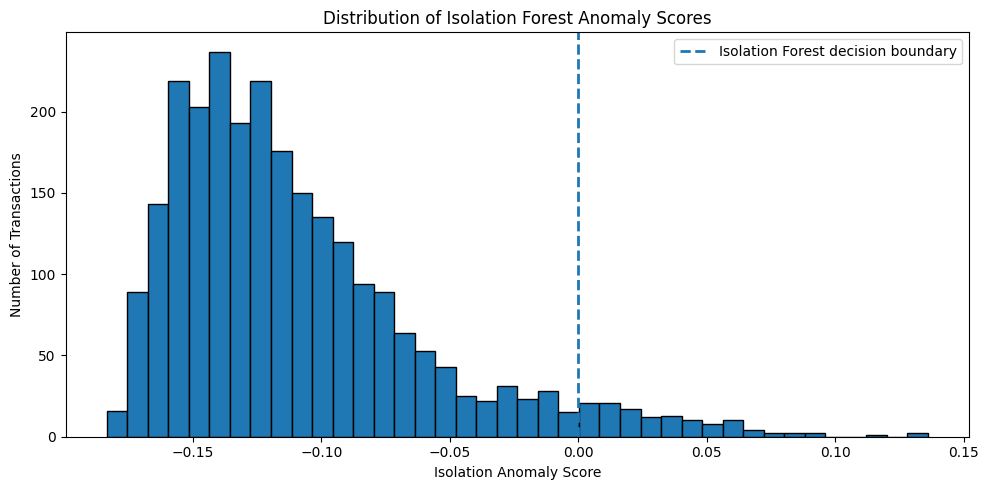

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    df["IsolationAnomalyScore"],
    bins=40,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="Isolation Forest decision boundary"
)

plt.xlabel("Isolation Anomaly Score")
plt.ylabel("Number of Transactions")
plt.title("Distribution of Isolation Forest Anomaly Scores")

plt.legend()
plt.tight_layout()
plt.show()

In [32]:
score_based_anomaly = (
    df["IsolationAnomalyScore"] > 0
).astype(int)

agreement = (
    score_based_anomaly == df["IsAnomaly_IF"]
).mean()

print(
    "Score/label agreement:",
    round(agreement * 100, 2),
    "%"
)

print(
    "Transactions with score > 0:",
    (df["IsolationAnomalyScore"] > 0).sum()
)

print(
    "Transactions labelled anomalous:",
    df["IsAnomaly_IF"].sum()
)

Score/label agreement: 100.0 %
Transactions with score > 0: 126
Transactions labelled anomalous: 126


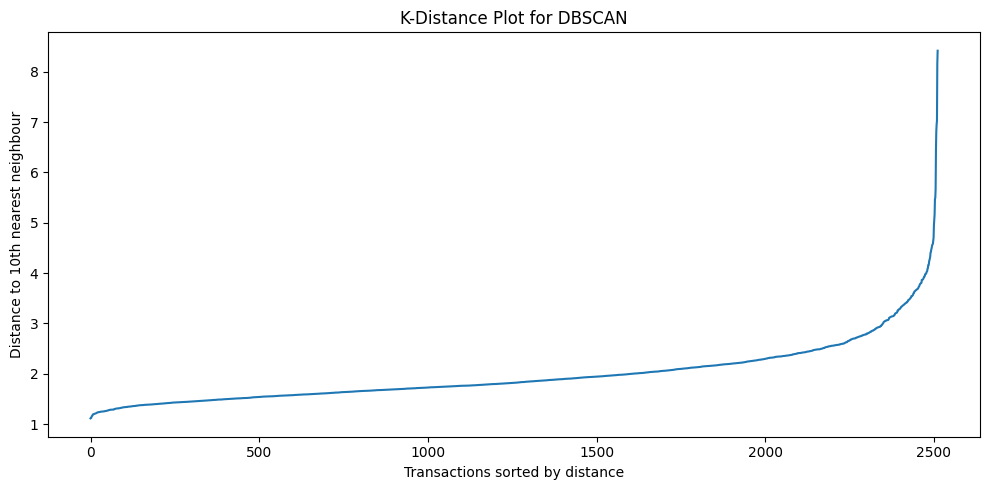

In [33]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

min_samples = 10

neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

neighbors_fit = neighbors.fit(X_anomaly_scaled)

distances, indices = neighbors_fit.kneighbors(
    X_anomaly_scaled
)

# Distance to each point's 10th nearest neighbour
k_distances = np.sort(
    distances[:, min_samples - 1]
)

plt.figure(figsize=(10, 5))

plt.plot(k_distances)

plt.xlabel("Transactions sorted by distance")
plt.ylabel("Distance to 10th nearest neighbour")
plt.title("K-Distance Plot for DBSCAN")

plt.tight_layout()
plt.show()

In [34]:
from sklearn.cluster import DBSCAN

eps_values = [2.5, 3.0, 3.25, 3.5, 4.0]

dbscan_results = []

for eps in eps_values:
    model = DBSCAN(
        eps=eps,
        min_samples=10
    )

    labels = model.fit_predict(X_anomaly_scaled)

    n_noise = (labels == -1).sum()
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    dbscan_results.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_points": n_noise,
        "noise_percentage": round(
            n_noise / len(labels) * 100,
            2
        )
    })

dbscan_results_df = pd.DataFrame(dbscan_results)

dbscan_results_df

,eps,clusters,noise_points,noise_percentage
0,2.50,2,172,6.85
1,3.00,2,66,2.63
2,3.25,2,40,1.59
3,3.50,2,26,1.04
4,4.00,2,10,0.40


In [35]:
dbscan = DBSCAN(
    eps=3.0,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(
    X_anomaly_scaled
)

df["DBSCANCluster"] = dbscan_labels

# DBSCAN uses -1 for noise
df["IsAnomaly_DBSCAN"] = (
    df["DBSCANCluster"] == -1
).astype(int)

print("DBSCAN results")
print("----------------")

print(
    "Clusters:",
    len(set(dbscan_labels))
    - (1 if -1 in dbscan_labels else 0)
)

print(
    "Noise / anomaly transactions:",
    df["IsAnomaly_DBSCAN"].sum()
)

print(
    "Percentage flagged:",
    round(
        df["IsAnomaly_DBSCAN"].mean() * 100,
        2
    ),
    "%"
)

print("\nCluster distribution:")
print(df["DBSCANCluster"].value_counts().sort_index())

DBSCAN results
----------------
Clusters: 2
Noise / anomaly transactions: 66
Percentage flagged: 2.63 %

Cluster distribution:
DBSCANCluster
-1      66
 0    2367
 1      79
Name: count, dtype: int64


In [36]:
anomaly_agreement = pd.crosstab(
    df["IsAnomaly_IF"],
    df["IsAnomaly_DBSCAN"],
    rownames=["Isolation Forest"],
    colnames=["DBSCAN"]
)

print("Isolation Forest vs DBSCAN")
print("--------------------------")
print(anomaly_agreement)

both_anomaly = (
    (df["IsAnomaly_IF"] == 1)
    & (df["IsAnomaly_DBSCAN"] == 1)
).sum()

if_only = (
    (df["IsAnomaly_IF"] == 1)
    & (df["IsAnomaly_DBSCAN"] == 0)
).sum()

dbscan_only = (
    (df["IsAnomaly_IF"] == 0)
    & (df["IsAnomaly_DBSCAN"] == 1)
).sum()

neither = (
    (df["IsAnomaly_IF"] == 0)
    & (df["IsAnomaly_DBSCAN"] == 0)
).sum()

print("\nAgreement breakdown")
print("-------------------")
print("Flagged by BOTH:", both_anomaly)
print("Isolation Forest only:", if_only)
print("DBSCAN only:", dbscan_only)
print("Flagged by neither:", neither)

Isolation Forest vs DBSCAN
--------------------------
DBSCAN               0   1
Isolation Forest          
0                 2369  17
1                   77  49

Agreement breakdown
-------------------
Flagged by BOTH: 49
Isolation Forest only: 77
DBSCAN only: 17
Flagged by neither: 2369


In [37]:
consensus_anomalies = (
    df[
        (df["IsAnomaly_IF"] == 1)
        & (df["IsAnomaly_DBSCAN"] == 1)
    ]
    .sort_values(
        "IsolationAnomalyScore",
        ascending=False
    )
)

print(
    "Consensus anomalies:",
    len(consensus_anomalies)
)

consensus_anomalies[
    [
        "TransactionID",
        "AccountID",
        "TransactionAmount",
        "AccountBalance",
        "TransactionDuration",
        "LoginAttempts",
        "AccountTransactionCount",
        "AmountDeviationFromAccountAvg",
        "AmountDeviationZScore",
        "TransactionToBalanceRatio",
        "TransactionToAccountAvgRatio",
        "IsolationAnomalyScore",
        "DBSCANCluster"
    ]
].head(15)

Consensus anomalies: 49


,TransactionID,AccountID,TransactionAmount,AccountBalance,TransactionDuration,LoginAttempts,AccountTransactionCount,AmountDeviationFromAccountAvg,AmountDeviationZScore,TransactionToBalanceRatio,TransactionToAccountAvgRatio,IsolationAnomalyScore,DBSCANCluster
898,TX000899,AC00083,1531.31,859.86,62,4,6,1072.413333,1.869265,1.778814,3.329683,0.136035,-1
274,TX000275,AC00454,1176.28,323.69,174,5,4,682.097500,1.448973,3.622779,2.375447,0.128301,-1
1213,TX001214,AC00170,1192.20,7816.41,103,5,7,944.874286,2.249026,0.152506,4.800953,0.114565,-1
2149,TX002150,AC00110,1250.94,11565.97,107,2,8,937.468750,2.347715,0.108148,3.977915,0.092599,-1
147,TX000148,AC00161,514.95,421.93,142,5,4,23.475000,0.047182,1.217577,1.045637,0.088849,-1
934,TX000935,AC00456,1022.75,207.74,158,1,11,741.786364,2.408272,4.899636,3.627241,0.087696,-1
231,TX000232,AC00430,705.60,14804.70,124,3,7,495.170000,1.983812,0.047657,3.337275,0.086036,-1
394,TX000395,AC00326,6.30,7697.68,283,5,5,231.908000,1.259963,0.000818,0.026337,0.073736,-1
1774,TX001775,AC00358,17.79,2281.90,162,5,8,432.263750,0.766624,0.007793,0.039441,0.072643,-1
1731,TX001732,AC00333,1.93,5684.09,175,5,3,176.916667,0.829979,0.000339,0.010731,0.069421,-1


In [38]:
profile_features = [
    "TransactionAmount",
    "AccountBalance",
    "TransactionDuration",
    "LoginAttempts",
    "AccountTransactionCount",
    "AmountDeviationFromAccountAvg",
    "AmountDeviationZScore",
    "TransactionToBalanceRatio",
    "TransactionToAccountAvgRatio"
]

consensus_profile = pd.DataFrame({
    "Overall_Mean": df[profile_features].mean(),
    "Consensus_Anomaly_Mean": consensus_anomalies[profile_features].mean()
})

consensus_profile["Consensus_vs_Overall_Ratio"] = (
    consensus_profile["Consensus_Anomaly_Mean"]
    / consensus_profile["Overall_Mean"]
)

consensus_profile.round(3)

,Overall_Mean,Consensus_Anomaly_Mean,Consensus_vs_Overall_Ratio
TransactionAmount,297.594,606.365,2.038
AccountBalance,5114.303,5033.626,0.984
TransactionDuration,119.643,149.102,1.246
LoginAttempts,1.125,3.061,2.722
AccountTransactionCount,6.110,6.612,1.082
AmountDeviationFromAccountAvg,196.462,385.867,1.964
AmountDeviationZScore,0.751,1.097,1.461
TransactionToBalanceRatio,0.199,1.269,6.360
TransactionToAccountAvgRatio,0.996,1.669,1.676


In [39]:
def assign_anomaly_confidence(row):
    if row["IsAnomaly_IF"] == 1 and row["IsAnomaly_DBSCAN"] == 1:
        return "High"
    elif row["IsAnomaly_IF"] == 1 or row["IsAnomaly_DBSCAN"] == 1:
        return "Medium"
    else:
        return "Low"


df["AnomalyConfidence"] = df.apply(
    assign_anomaly_confidence,
    axis=1
)

print("Anomaly confidence distribution")
print("-------------------------------")
print(df["AnomalyConfidence"].value_counts())

print("\nPercentage distribution")
print("-----------------------")
print(
    (df["AnomalyConfidence"].value_counts(normalize=True) * 100)
    .round(2)
)

Anomaly confidence distribution
-------------------------------
AnomalyConfidence
Low       2369
Medium      94
High        49
Name: count, dtype: int64

Percentage distribution
-----------------------
AnomalyConfidence
Low       94.31
Medium     3.74
High       1.95
Name: proportion, dtype: float64


In [40]:
investigation_columns = [
    "TransactionID",
    "AccountID",
    "TransactionAmount",
    "AccountBalance",
    "TransactionDuration",
    "LoginAttempts",
    "AccountAvgTransactionAmount",
    "AmountDeviationFromAccountAvg",
    "AmountDeviationZScore",
    "TransactionToBalanceRatio",
    "TransactionToAccountAvgRatio",
    "IsolationAnomalyScore",
    "IsAnomaly_IF",
    "DBSCANCluster",
    "IsAnomaly_DBSCAN",
    "AnomalyConfidence"
]

anomaly_investigation_table = (
    df[df["AnomalyConfidence"].isin(["High", "Medium"])]
    [investigation_columns]
    .copy()
)

confidence_order = {
    "High": 0,
    "Medium": 1
}

anomaly_investigation_table["ConfidenceOrder"] = (
    anomaly_investigation_table["AnomalyConfidence"]
    .map(confidence_order)
)

anomaly_investigation_table = (
    anomaly_investigation_table
    .sort_values(
        ["ConfidenceOrder", "IsolationAnomalyScore"],
        ascending=[True, False]
    )
    .drop(columns="ConfidenceOrder")
    .reset_index(drop=True)
)

print(
    "Transactions requiring anomaly investigation:",
    len(anomaly_investigation_table)
)

anomaly_investigation_table.head(20)

Transactions requiring anomaly investigation: 143


,TransactionID,AccountID,TransactionAmount,AccountBalance,TransactionDuration,LoginAttempts,AccountAvgTransactionAmount,AmountDeviationFromAccountAvg,AmountDeviationZScore,TransactionToBalanceRatio,TransactionToAccountAvgRatio,IsolationAnomalyScore,IsAnomaly_IF,DBSCANCluster,IsAnomaly_DBSCAN,AnomalyConfidence
0,TX000899,AC00083,1531.31,859.86,62,4,458.896667,1072.413333,1.869265,1.778814,3.329683,0.136035,1,-1,1,High
1,TX000275,AC00454,1176.28,323.69,174,5,494.182500,682.097500,1.448973,3.622779,2.375447,0.128301,1,-1,1,High
2,TX001214,AC00170,1192.20,7816.41,103,5,247.325714,944.874286,2.249026,0.152506,4.800953,0.114565,1,-1,1,High
3,TX002150,AC00110,1250.94,11565.97,107,2,313.471250,937.468750,2.347715,0.108148,3.977915,0.092599,1,-1,1,High
4,TX000148,AC00161,514.95,421.93,142,5,491.475000,23.475000,0.047182,1.217577,1.045637,0.088849,1,-1,1,High
5,TX000935,AC00456,1022.75,207.74,158,1,280.963636,741.786364,2.408272,4.899636,3.627241,0.087696,1,-1,1,High
6,TX000232,AC00430,705.60,14804.70,124,3,210.430000,495.170000,1.983812,0.047657,3.337275,0.086036,1,-1,1,High
7,TX000395,AC00326,6.30,7697.68,283,5,238.208000,231.908000,1.259963,0.000818,0.026337,0.073736,1,-1,1,High
8,TX001775,AC00358,17.79,2281.90,162,5,450.053750,432.263750,0.766624,0.007793,0.039441,0.072643,1,-1,1,High
9,TX001732,AC00333,1.93,5684.09,175,5,178.846667,176.916667,0.829979,0.000339,0.010731,0.069421,1,-1,1,High


In [41]:
from pathlib import Path

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "transaction_anomaly_results.csv"

anomaly_investigation_table.to_csv(
    output_path,
    index=False
)

print("Saved anomaly investigation dataset.")
print("Location:", output_path)
print("Rows saved:", len(anomaly_investigation_table))
print("Columns saved:", len(anomaly_investigation_table.columns))

Saved anomaly investigation dataset.
Location: ..\data\processed\transaction_anomaly_results.csv
Rows saved: 143
Columns saved: 16
